# 🚢 Titanic — Survival Prediction

> Kaggle competition: [Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic/overview)

### Overview

On April 15, 1912, the RMS Titanic sank after colliding with an iceberg, killing 1,502 of 2,224 passengers and crew. While survival involved some luck, certain groups had notably higher chances.

**Goal:** build a model to predict which passengers survived, using features like age, sex, and passenger class.

### Workflow

1. Exploratory Data Analysis
2. Feature Engineering
3. Preprocessing Pipeline
4. Model Training & Tuning
5. Results & Submission

# 1. Exploratory Data Analysis

The exploratory analysis aims to identify patterns related to survival.

Some hypotheses investigated:
- Did women survive more often?
- Did passenger class impact survival?
- Did traveling alone influence survival probability?

### Data Dictionary

| Variable | Definition | Key |
|----------|-----------|-----|
| `Survived` | Survival | 0 = No, 1 = Yes |
| `Pclass` | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| `Sex` | Sex | |
| `Age` | Age in years | |
| `SibSp` | # siblings / spouses aboard | |
| `Parch` | # parents / children aboard | |
| `Ticket` | Ticket number | |
| `Fare` | Passenger fare | |
| `Cabin` | Cabin number | |
| `Embarked` | Port of embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin

In [94]:
titanic = pd.read_csv("train.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


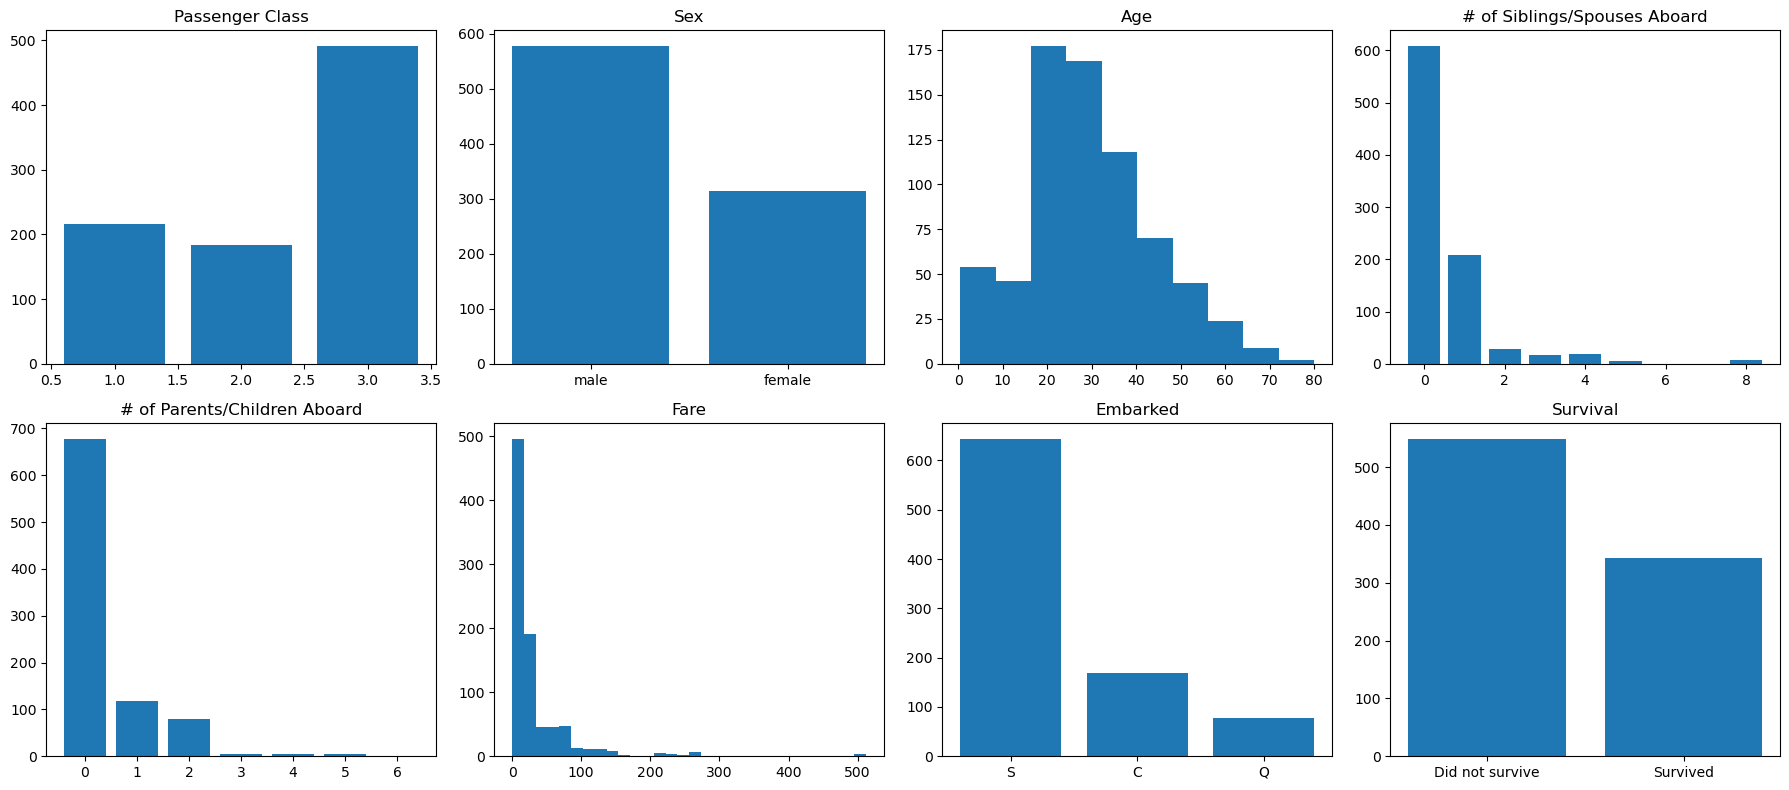

In [95]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()

# 1. Pclass
pclass_counts = titanic["Pclass"].value_counts().sort_index()
ax1.bar(pclass_counts.index, pclass_counts.values)
ax1.set_title("Passenger Class")

# 2. Sex
sex_counts = titanic["Sex"].value_counts()
ax2.bar(sex_counts.index, sex_counts.values)
ax2.set_title("Sex")

# 3. Age
ax3.hist(titanic["Age"])
ax3.set_title("Age")

# 4. SibSp
sibsp_counts = titanic["SibSp"].value_counts().sort_index()
ax4.bar(sibsp_counts.index, sibsp_counts.values)
ax4.set_title("# of Siblings/Spouses Aboard")

# 5. Parch
parch_counts = titanic["Parch"].value_counts().sort_index()
ax5.bar(parch_counts.index, parch_counts.values)
ax5.set_title("# of Parents/Children Aboard")

# 6. Fare
ax6.hist(titanic["Fare"], bins=30)
ax6.set_title("Fare")

# 7. Embarked
embarked_counts = titanic["Embarked"].value_counts()
ax7.bar(embarked_counts.index, embarked_counts.values)
ax7.set_title("Embarked")

# 8. Survived
survived_counts = titanic["Survived"].value_counts().sort_index()
ax8.bar(["Did not survive", "Survived"], survived_counts.values)
ax8.set_title("Survival")

plt.tight_layout()

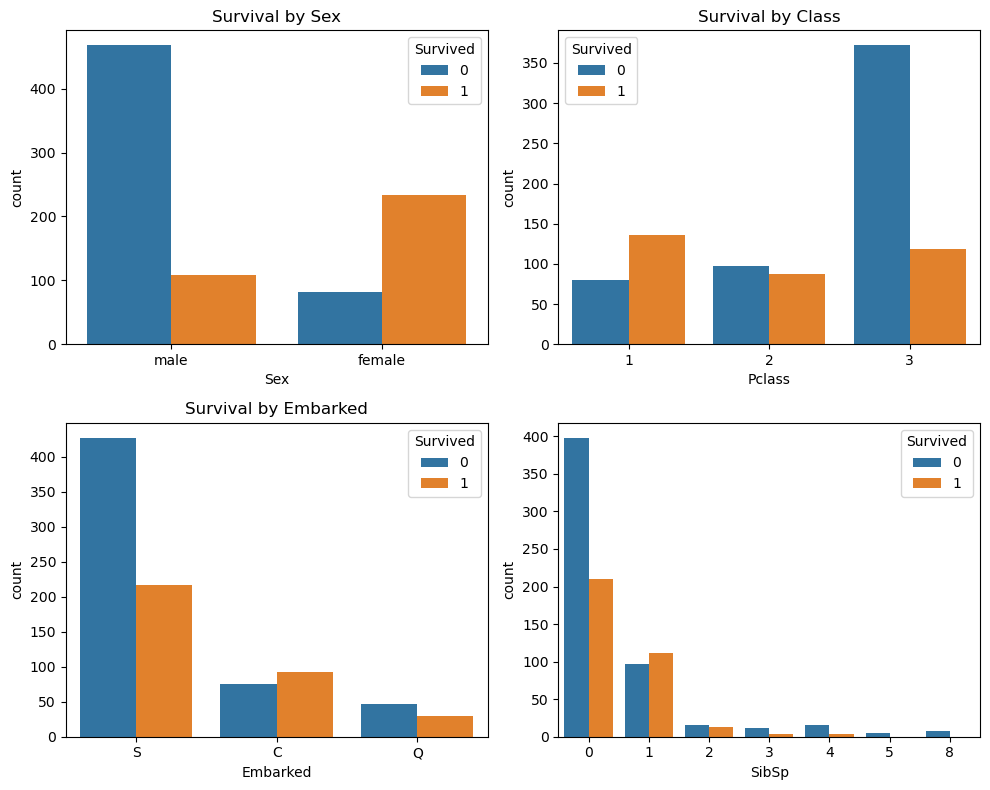

In [96]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(10, 8)
)

# 1. Sex vs Survived
sns.countplot(data=titanic, x="Sex", hue="Survived", ax=ax1)
ax1.set_title("Survival by Sex")

# 2. Pclass vs Survived
sns.countplot(data=titanic, x="Pclass", hue="Survived", ax=ax2)
ax2.set_title("Survival by Class")

# 3. Embarked vs Survived
sns.countplot(data=titanic, x="Embarked", hue="Survived", ax=ax3)
ax3.set_title("Survival by Embarked")

# 6. SibSp vs Survived
sns.countplot(data=titanic, x="SibSp", hue="Survived", ax=ax4)
ax6.set_title("Survival by SibSp")

plt.tight_layout()
plt.show()

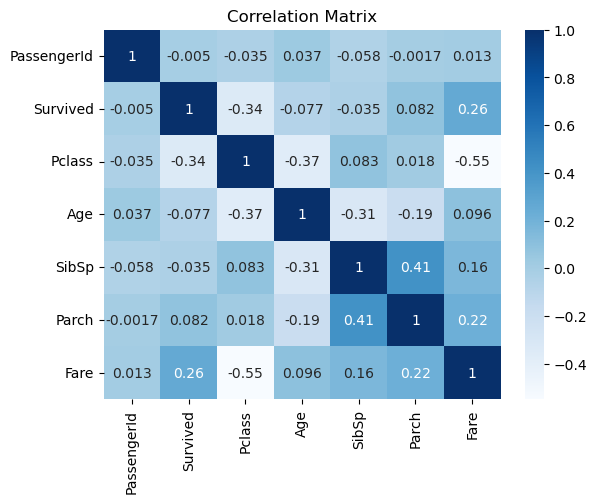

In [97]:
corr = titanic.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

### Key insights from the EDA

- Women had significantly higher survival rates.
- First-class passengers survived more frequently.
- Higher fares appear correlated with survival.
- Passengers traveling alone had lower survival rates.

# 2. Feature Engineering

Custom features capture hidden patterns not present in the raw data:

| Feature | Rationale |
|---------|----------|
| `FamilySize` | Family members may have coordinated during evacuation |
| `IsAlone` | Solo passengers may have had different survival behavior |
| `Title` | The title may contain information abou age and class |

In [101]:
class FeatureCreate(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        ########## THE ADDITION OF THIS FEATURES WAS NOT IMPROVING THE CLASSIFIER ACCURACY#########
        # Title
        #X["Title"] = (
        #    X["Name"]
        #    .str.extract(r',\s*([^\.]+)\.')
        #)

        #rare_titles = [
         #   "Lady", "Countess", "Capt", "Col", "Don",
         #   "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"
        #]

        #X["Title"] = X["Title"].replace(rare_titles, "Rare")

        # Family size
        X["FamSz"] = X["SibSp"] + X["Parch"] + 1

        # Alone
        X["IsAlone"] = (X["FamSz"] == 1).astype(int)

        # Feature Drop
        X.drop(["Name", "Cabin", "Ticket", "FamSz", "SibSp", "Parch"], axis=1)

        return X
    

### 1.2 Creating transformers

In [102]:
# Define different features and transformer pipeline
categorical_features = ["Sex", "Embarked", "IsAlone"]
categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))])

numeric_features = [
    "Age",
    "Fare",
    "Pclass",
]
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Setup preprocessing steps (fill missing values, then convert to numbers)
preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, categorical_features),
    ("num", numeric_transformer, numeric_features),
])

### 1.3 Creating the pipeline

In this project the usage of pipeline recalls to:
- avoid data leakage;
- organize preprocessing steps;
- ensure reproducibility;
- simplify hyperparameter tuning.

In [103]:
# Creating a preprocessing and modelling pipeline
clf = Pipeline(steps=[("feature_creation", FeatureCreate()),
                        ("preprocessor", preprocessor),
                        ("clf", RandomForestClassifier())])

Random Forest was chosen because:

- it handles nonlinear relationships well;
- it is robust to noisy features;
- it requires little feature scaling;
- it generally performs well on structured/tabular datasets.
  ![Scikit-Learn models map](scikit-learn-map.jpg)


## 2. Fitting the data into the model

### 2.1 Splitting the data into `X` and `y`

In [104]:
# Split data
X = titanic.drop("Survived", axis=1)
y = titanic["Survived"]

### 2.2 Using `GridSearchCV()` to achieve the best combination of parameters

In [105]:
pipe_grid = {
    "clf__n_estimators": [10, 100, 200],
    "clf__max_depth": [4, 5, 8, None]}

gs_clf = GridSearchCV(clf, pipe_grid, cv=5)
gs_clf.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__max_depth': [4, 5, ...], 'clf__n_estimators': [10, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

In [112]:
print(f"Best results shown with {gs_clf.best_params_} and score {gs_clf.best_score_}")

Best results shown with {'clf__max_depth': 8, 'clf__n_estimators': 100} and score 0.8226916075575922


## 3. Creating the output file for submission and evaluation at Kaggle

In [107]:
titanic_test = pd.read_csv("test.csv")
predictions = gs_clf.predict(titanic_test)

output = pd.DataFrame({'PassengerId': titanic_test.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


This project demonstrated the complete workflow of a machine learning problem:

- data exploration;
- preprocessing;
- feature engineering;
- pipeline construction;
- hyperparameter optimization.

The final Random Forest model achieved competitive Kaggle performance while maintaining a clean and reproducible workflow.